# Phase 3 — Feature Engineering

Builds the time-derived and cyclic features defined in `src/bike_sharing/features.py` and verifies them against the training data. Three checks: cyclic encoding sanity, the hour × workingday interaction strength from Phase 2 EDA, and a first-pass correlation of each new feature with `count`. The production parquet is produced by `scripts/prepare_data.py`, not by this notebook.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from bike_sharing.config import load_config
from bike_sharing.data import load_raw_train
from bike_sharing.features import (
    ADDED_FEATURE_COLUMNS,
    CYCLIC_FEATURE_COLUMNS,
    build_features,
)

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "config" / "config.yaml").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not locate config/config.yaml above cwd.")
    PROJECT_ROOT = PROJECT_ROOT.parent

CFG = load_config(PROJECT_ROOT / "config" / "config.yaml")
FIG_DIR = Path(CFG["paths"]["reports_dir"]) / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(context="notebook", style="whitegrid")
print("added feature columns:", list(ADDED_FEATURE_COLUMNS))


added feature columns: ['hour', 'dayofweek', 'month', 'year', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']


## 1. Apply `build_features` to the training frame

Confirms that nine new columns are added with sensible dtypes and ranges. `datetime` is preserved so the same pipeline can later be applied to the test set and label its predictions.

In [2]:
raw = load_raw_train(CFG)
df = build_features(raw, CFG)
print("raw shape:", raw.shape, "  featured shape:", df.shape)
print("new columns added:")
for col in ADDED_FEATURE_COLUMNS:
    print(f"  {col:12s}  dtype={df[col].dtype}  range=[{df[col].min()}, {df[col].max()}]")
df.head()


raw shape: (10886, 12)   featured shape: (10886, 21)
new columns added:
  hour          dtype=int16  range=[0, 23]
  dayofweek     dtype=int16  range=[0, 6]
  month         dtype=int16  range=[1, 12]
  year          dtype=int16  range=[2011, 2012]
  is_weekend    dtype=int8  range=[0, 1]
  hour_sin      dtype=float32  range=[-1.0, 1.0]
  hour_cos      dtype=float32  range=[-1.0, 1.0]
  month_sin     dtype=float32  range=[-1.0, 1.0]
  month_cos     dtype=float32  range=[-1.0, 1.0]


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,...,count,hour,dayofweek,month,year,is_weekend,hour_sin,hour_cos,month_sin,month_cos
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,...,16,0,5,1,2011,1,0.000000,1.000000,0.0,1.0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,...,40,1,5,1,2011,1,0.258819,0.965926,0.0,1.0
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,...,32,2,5,1,2011,1,0.500000,0.866025,0.0,1.0
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,...,13,3,5,1,2011,1,0.707107,0.707107,0.0,1.0
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,...,1,4,5,1,2011,1,0.866025,0.500000,0.0,1.0


## 2. Cyclic encoding sanity

Each of the 24 hours maps to a unique point on the unit circle. The right-hand plot visualizes that mapping: hour 0 sits at (0, 1), hour 6 at (1, 0), and hour 23 is geometrically adjacent to hour 0 — the property the encoding exists to provide.

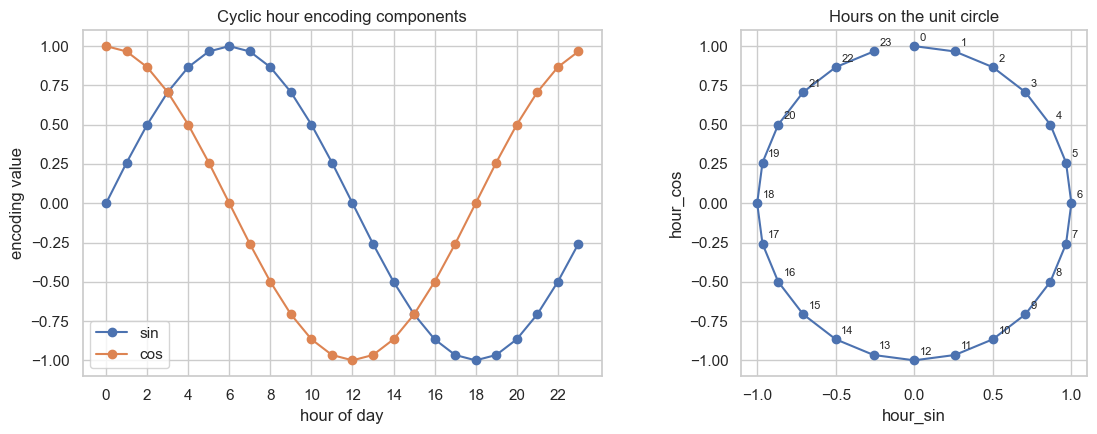

In [3]:
# Cyclic encoding sanity: each hour maps to a unique point on the unit
# circle, and hour 23 is adjacent to hour 0 in (sin, cos) space.
hour_summary = (
    df[["hour", "hour_sin", "hour_cos"]].drop_duplicates().sort_values("hour")
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(hour_summary["hour"], hour_summary["hour_sin"], "o-", label="sin")
axes[0].plot(hour_summary["hour"], hour_summary["hour_cos"], "o-", label="cos")
axes[0].set_title("Cyclic hour encoding components")
axes[0].set_xlabel("hour of day")
axes[0].set_ylabel("encoding value")
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend()

axes[1].plot(hour_summary["hour_sin"], hour_summary["hour_cos"], "o-")
for _, row in hour_summary.iterrows():
    axes[1].annotate(int(row["hour"]),
                     (row["hour_sin"], row["hour_cos"]),
                     textcoords="offset points", xytext=(4, 4), fontsize=8)
axes[1].set_title("Hours on the unit circle")
axes[1].set_xlabel("hour_sin")
axes[1].set_ylabel("hour_cos")
axes[1].set_aspect("equal")
fig.tight_layout()
fig.savefig(FIG_DIR / "06_cyclic_hour_encoding.png", dpi=120, bbox_inches="tight")
plt.show()


## 3. Hour × workingday interaction

Re-plots the strongest temporal signal from Phase 2 on the engineered frame to confirm nothing was distorted. Working days still show a sharp double rush-hour pattern; non-working days a smoother afternoon peak.

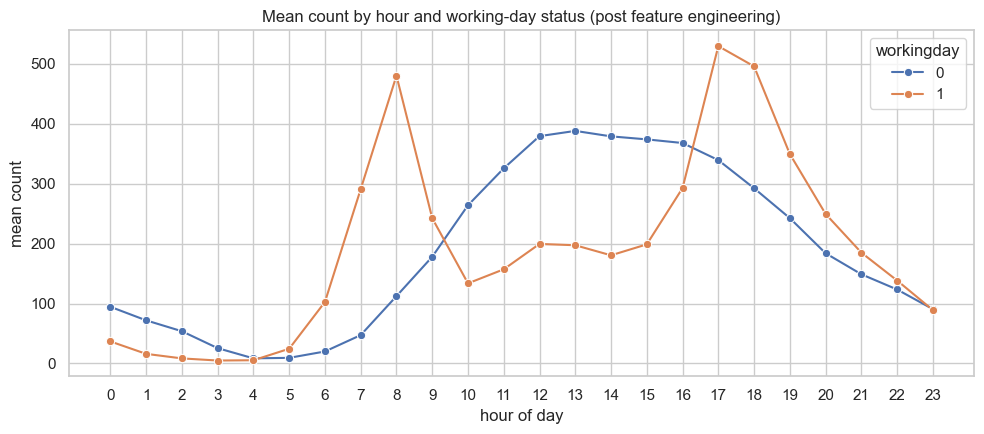

In [4]:
# Mean count at every hour, split by workingday. The Phase 2 EDA showed
# this interaction was the strongest temporal signal. Cyclic terms
# preserve hour wrap-around, but the two distinct workingday curves
# require richer Ridge features or interactions to be evaluated in Phase 4.
mean_by_hour_workday = (
    df.groupby(["hour", "workingday"], as_index=False)["count"].mean()
)
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.lineplot(
    data=mean_by_hour_workday, x="hour", y="count",
    hue="workingday", marker="o", ax=ax,
)
ax.set_title("Mean count by hour and working-day status (post feature engineering)")
ax.set_xlabel("hour of day")
ax.set_ylabel("mean count")
ax.set_xticks(range(0, 24))
ax.legend(title="workingday")
fig.tight_layout()
fig.savefig(FIG_DIR / "07_hour_workingday_interaction.png", dpi=120, bbox_inches="tight")
plt.show()


## 4. New-feature correlations with target

First-pass diagnostic — Pearson correlation of each engineered feature with `count`. Sign and magnitude are sanity checks, not modeling decisions: feature value is judged by Phase 4 CV, not by raw correlations.

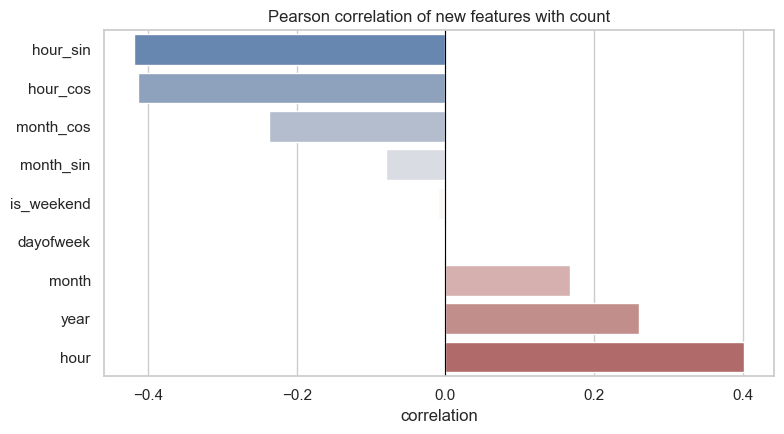

In [5]:
# Correlation of new features with the target on the original scale.
# Cyclic encodings should show non-trivial correlations; year captures
# yearly growth.
feature_cols = list(ADDED_FEATURE_COLUMNS) + ["count"]
corr = df[feature_cols].corr()["count"].drop("count").sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=corr.values, y=corr.index, hue=corr.index, legend=False, palette="vlag", ax=ax)
ax.set_title("Pearson correlation of new features with count")
ax.set_xlabel("correlation")
ax.set_ylabel("")
ax.axvline(0, color="black", linewidth=0.8)
fig.tight_layout()
fig.savefig(FIG_DIR / "08_new_feature_target_correlation.png", dpi=120, bbox_inches="tight")
plt.show()


## Findings (feed into Phase 4 modeling)

- The cyclic hour encoding represents cyclicity: hour 23 is adjacent to hour 0 on the unit circle (verified by `test_cyclic_encoding_continuity`). First-harmonic sin/cos alone can express at most one peak per 24h — it does **not** give a linear model the bimodal commuter pattern for free.
- The hour × workingday interaction shows two distinct hourly shapes: a sharp morning + evening double-peak on working days and a smoother single afternoon peak on non-working days. Tree models can pick this up from raw `hour` + `workingday`. Ridge with only additive `hour_sin`, `hour_cos`, `workingday` cannot represent two different hourly curves at once.
- Phase 4 will therefore compare, for the linear model: `hour` one-hot, an explicit `hour × workingday` interaction term, and additional Fourier harmonics. The current cyclic columns are a starting point, not a finished solution.
- Among the new features, `hour`, `year`, and the cyclic columns show the strongest single-feature correlations with `count`. `is_weekend` is weakly correlated because `workingday` already captures most weekend behavior.
- `day` (day-of-month) is intentionally excluded from the feature set: the dataset's split puts days 1-19 in train and 20-31 in test, so the feature would be out-of-distribution at test time. The schema-contract test `test_train_and_test_predictor_schemas_match` prevents this regression from reappearing.